<a href="https://colab.research.google.com/github/turryhit/data-analytics-public/blob/main/2026_04_07__Exploring_Maritime_Data_Optional_Python_Pandas_Time_Series_Exercise_(Helene_Turry).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploring the Maritime World - Exercise Instructions

Let's explore the maritime world. In this dataset: https://noaaocm.blob.core.windows.net/ais/csv2/csv2025/ais-2025-01-08.csv.zst, you'll be able to visualize all the positions of ships off US coasts for one day: 01/08/2025. You can look this URL up directly in pandas, it can handle the decompression (this is a compressed CSV). This is a **large** dataset, so your operations may take longer than what we've seen so far. To understand what each column is, here is the data dictionary: https://coast.noaa.gov/data/marinecadastre/ais/data-dictionary.pdf

Please provide a notebook (.ipynb file) posted here and on your Github, in your data-analytics repo (please add a link to the repo in your submission) with the following:

- Load the dataframe
- Set the index to the **base_date_time**. Your index should be a DateTimeIndex
- Clean the data: we don't want any row where the **sog** is null
- First Analysis: When are boats out? Display a line graph where your x-axis is the hour of the day, and the y-axis is the number of unique vessels out at that hour. Hint: the MMSI column is a great way to identity a unique vessel. What time (UTC) saw the most boats out on the water? And the least? Does this track with what you could expect?
- Second Analysis: let's look at a specific boat, the Henry Hudson (MMSI: 366651000). The owner of the boat has asked us how long the boat engines were active for that day. To get to this, you must:

- a) Figure out when the boat was "accelerating". Create a column called "acceleration", which is going to be the difference between each "sog". Hints: to achieve this, use the "diff()" function on your column. **Be sure that your index is sorted, meaning the rows are sorted by time (.sort_index() is very helpful for this)**

- b) Create a duration column, which is the difference between each "base_date_time"

- c) Once you have a column "acceleration" and "duration", we can assume that the boat engines were active if the "acceleration" is greater than 0. Filter your dataframe to only have rows where the acceleration is positive.

- d) Sum up the "duration" column to see how long the engines were active for that day. This will allow us to answer the boat captain

**Bonus**: create a function that takes the MMSI as a parameter, and return the active engine time for that day. Name this function **calculate_total_active_engine_time**.


# Data Dictionary - Automatic Identification System (AIS) Data 2025-Present

**Field Name, Description, Example, Unit, Valid Domain, Null Allowed, Arrow Type, Bytes, Query**

1. **mmsi**: Maritime Mobile Service
Identity value 477220100 integer 2-7 + MIDx3 + 4 N int32 4 Y

2. **base_date_time**: Full UTC date and time 2017-02-01T20:05:07 - - N datetime64[ns] 8 Y

3. longitude: Longitude -71.04182 decimal
degree -179.99999 to 179.99999 N double 8 Y

4. latitude: Latitude 42.35137 decimal
degree -89.99999 to 89.99999 N double 8 Y

5. **sog**: Speed Over Ground 5.9 knot 0 to 99.9 Y float 4 Y

6. cog: Course Over Ground 47.5 degree NAz 0 to 359.9 Y float 4 -

7. heading: True Heading 45 degree NAz 0 to 359 Y int32 4 -

8. **vessel_name**: Name as shown on the
station radio license OOCL Malaysia alphanumeric ASCII characters UTF-8 Y string 24 Y

9. imo:
International Maritime
Organization Vessel
number
IMO9627980 alphanumeric alphanumeric Y string 12 Y

10. call_sign: Call sign as assigned by
FCC VRME7 alphanumeric alphanumeric Y string 8 Y

11. vessel_type: Vessel type as defined in
NAIS specifications 70 scalar 1 to 1024* Y int32 4 Y

12. status: Navigation status as
defined by the COLREGS 3 scalar 1 to 14* Y int32 4 Y

13. length: Length of vessel (see NAIS
specifications) 71 meter 1 to 509 Y int32 4 Y

14. width: Width of vessel (see NAIS
specifications) 12 meter 1 to 61 Y int32 4 Y

15. draft: Draft depth of vessel (see
NAIS specifications) 3.5 meter 1 to 24 Y float 4 Y

16. cargo:
Cargo type (see NAIS
specification and codes) 70 scalar 1 to 1024* Y int32 4 -

17. transceiver: Class of AIS transceiver A character A | B Y string 2 Y

*Applicable lookup table required

## Cargo Types (https://coast.noaa.gov/data/marinecadastre/ais/VesselTypeCodes2018.pdf)
AIS Ship Type Code Vessel Group:
70-79 Cargo


# Loading the data

In [1]:
# set the URL
URL = "https://noaaocm.blob.core.windows.net/ais/csv2/csv2025/ais-2025-01-08.csv.zst"

In [2]:
# load the dataframe
import pandas as pd
df = pd.read_csv(URL)

### Look at the data before proceeding with the analysis

In [3]:
df.shape
df.columns
df.describe()
df.head()
df.value_counts("base_date_time")
df[df["sog"] > 0].tail().sort_values("base_date_time")
df.dtypes
df.base_date_time.dtype

dtype('O')

# Setting the Index

In [4]:
# We can view the index of the DataFrame by using df.index
print(f"The index is: {df.index}")
# Since we did not specify otherwise when we loaded the csv, by default, we have an index that represents the ORIGINAL row position
print(f"The number of rows is: {len(df)}")

The index is: RangeIndex(start=0, stop=5929631, step=1)
The number of rows is: 5929631


In [5]:
# We want to set the the index to the base_date_time. The index should be a DateTimeIndex
# We can first check to see if base_date_time is unique (all the values in it are unique)
if (df["base_date_time"].is_unique):
  print("The base_date_time is unique.")
else:
  print("The base_date_time is not unique.")

# Even though base_date_time is not unique, we can still set it as a DateTimeIndex because we are not using it as a primary key. A DateTimeIndex does not require uniqueness. In this dataset, we expect that multiple vessels may report their data at the same timestamp. We will use the base_date_time as an index to analyze the data over time rather than to identify particular vessels.

The base_date_time is not unique.


In [6]:
# Check to see if the base_date_time column is a timestamp. Even though the data dictionary description indicates "Full UTC date and time", we want to know what the data type of the column is in the pandas data frame to faciliate the Time Series analysis
print(f"The base_date_time column is of datatype: {df["base_date_time"].dtype}.")
df["base_date_time"].unique() # show the unique values
# The base_date_time column has string representations of the timestamp

The base_date_time column is of datatype: object.


array(['2025-01-08 00:00:00', '2025-01-08 00:00:01',
       '2025-01-08 00:00:10', ..., '2025-01-08 20:25:57',
       '2025-01-08 20:27:10', '2025-01-08 20:26:25'], dtype=object)

In [7]:
# Convert the base_date_time column to a timestamp in UTC format
# Note: I am choosing to work with a copy of the dataframe rather than updating
# in place since the dataset is quite large and takes a long time to load
# Using the copy, I can change the code and re-run without having to reload
df2 = df.copy()
print(f"Before conversion, the base_date_time column is of datatype: {df["base_date_time"].dtype}.")
print(df2.dtypes)
print(df2["base_date_time"].unique())

df2["base_date_time"] = pd.to_datetime(df2["base_date_time"],utc=True)

print()
print(f"After conversion, the base_date_time column is of datatype: {df["base_date_time"].dtype}.")

print(df2.dtypes)
df2["base_date_time"].unique()

Before conversion, the base_date_time column is of datatype: object.
mmsi                int64
base_date_time     object
longitude         float64
latitude          float64
sog               float64
cog               float64
heading           float64
vessel_name        object
imo                object
call_sign          object
vessel_type       float64
status            float64
length            float64
width             float64
draft             float64
cargo             float64
transceiver        object
dtype: object
['2025-01-08 00:00:00' '2025-01-08 00:00:01' '2025-01-08 00:00:10' ...
 '2025-01-08 20:25:57' '2025-01-08 20:27:10' '2025-01-08 20:26:25']

After conversion, the base_date_time column is of datatype: object.
mmsi                            int64
base_date_time    datetime64[ns, UTC]
longitude                     float64
latitude                      float64
sog                           float64
cog                           float64
heading                       float64
v

<DatetimeArray>
['2025-01-08 00:00:00+00:00', '2025-01-08 00:00:01+00:00',
 '2025-01-08 00:00:10+00:00', '2025-01-08 00:00:09+00:00',
 '2025-01-08 00:00:19+00:00', '2025-01-08 00:00:20+00:00',
 '2025-01-08 00:00:05+00:00', '2025-01-08 00:00:04+00:00',
 '2025-01-08 00:00:02+00:00', '2025-01-08 00:00:06+00:00',
 ...
 '2025-01-08 20:30:28+00:00', '2025-01-08 20:30:45+00:00',
 '2025-01-08 20:29:58+00:00', '2025-01-08 20:29:30+00:00',
 '2025-01-08 20:25:23+00:00', '2025-01-08 20:31:53+00:00',
 '2025-01-08 20:18:55+00:00', '2025-01-08 20:25:57+00:00',
 '2025-01-08 20:27:10+00:00', '2025-01-08 20:26:25+00:00']
Length: 86142, dtype: datetime64[ns, UTC]

In [8]:
# Set the index to the base_date_time (UTC timestamp)
df_datetime = df2.copy()
df_datetime = df2.set_index("base_date_time")

# confirm that is is a DatetimeIndex
print("The index has been set to: ")
print(df_datetime.index)

# NOTE: base_date_time is no longer a column because the set_index drop (default True, removes column)
print()
print("The columns of the dataframe are now:")
df_datetime.columns

The index has been set to: 
DatetimeIndex(['2025-01-08 00:00:00+00:00', '2025-01-08 00:00:00+00:00',
               '2025-01-08 00:00:01+00:00', '2025-01-08 00:00:10+00:00',
               '2025-01-08 00:00:09+00:00', '2025-01-08 00:00:10+00:00',
               '2025-01-08 00:00:19+00:00', '2025-01-08 00:00:20+00:00',
               '2025-01-08 00:00:05+00:00', '2025-01-08 00:00:04+00:00',
               ...
               '2025-01-08 23:21:37+00:00', '2025-01-08 23:26:18+00:00',
               '2025-01-08 23:36:28+00:00', '2025-01-08 23:39:28+00:00',
               '2025-01-08 18:01:42+00:00', '2025-01-08 18:58:42+00:00',
               '2025-01-08 19:49:42+00:00', '2025-01-08 21:13:42+00:00',
               '2025-01-08 22:07:42+00:00', '2025-01-08 23:34:42+00:00'],
              dtype='datetime64[ns, UTC]', name='base_date_time', length=5929631, freq=None)

The columns of the dataframe are now:


Index(['mmsi', 'longitude', 'latitude', 'sog', 'cog', 'heading', 'vessel_name',
       'imo', 'call_sign', 'vessel_type', 'status', 'length', 'width', 'draft',
       'cargo', 'transceiver'],
      dtype='object')

In [9]:
# Checking to make sure the timestamp attributes are available
# len(df_datetime)
# df_datetime.iloc[0:100]
# df_datetime[df_datetime.index.day_of_week == 2]
# df_datetime[df_datetime.index.month == 1]
# df_datetime[df_datetime.index.day_of_year < 10]
df_datetime[df_datetime.index.hour < 4].tail(10)

,mmsi,longitude,latitude,sog,cog,heading,vessel_name,imo,call_sign,vessel_type,status,length,width,draft,cargo,transceiver
base_date_time,,,,,,,,,,,,,,,,
2025-01-08 01:32:49+00:00,368367110,144.66463,13.46150,0.0,304.0,NaN,SENDALU,IMO9560601,J8B6564,52.0,0.0,26.0,8.0,3.8,52.0,A
2025-01-08 01:59:50+00:00,368367110,144.66462,13.46141,0.0,304.0,NaN,SENDALU,IMO9560601,J8B6564,52.0,0.0,26.0,8.0,3.8,52.0,A
2025-01-08 02:00:09+00:00,368367110,144.66462,13.46142,0.0,304.0,NaN,SENDALU,IMO9560601,J8B6564,52.0,0.0,26.0,8.0,3.8,52.0,A
2025-01-08 02:02:29+00:00,368367110,144.66462,13.46143,0.0,304.0,NaN,SENDALU,IMO9560601,J8B6564,52.0,0.0,26.0,8.0,3.8,52.0,A
2025-01-08 02:07:30+00:00,368367110,144.66462,13.46144,0.0,304.0,NaN,SENDALU,IMO9560601,J8B6564,52.0,0.0,26.0,8.0,3.8,52.0,A
2025-01-08 03:20:10+00:00,368367110,144.66457,13.46144,0.0,304.0,NaN,SENDALU,IMO9560601,J8B6564,52.0,0.0,26.0,8.0,3.8,52.0,A
2025-01-08 03:25:10+00:00,368367110,144.66456,13.46143,0.0,304.0,NaN,SENDALU,IMO9560601,J8B6564,52.0,0.0,26.0,8.0,3.8,52.0,A
2025-01-08 03:37:59+00:00,368367110,144.66467,13.46147,0.0,304.0,NaN,SENDALU,IMO9560601,J8B6564,52.0,0.0,26.0,8.0,3.8,52.0,A
2025-01-08 03:43:19+00:00,368367110,144.66466,13.46142,0.0,304.0,NaN,SENDALU,IMO9560601,J8B6564,52.0,0.0,26.0,8.0,3.8,52.0,A


# Cleaning the data

In [10]:
# We take a look at the number of NaN values per column
print("Before filtering:")
print("These are the null value counts:")
print(df_datetime.isnull().sum())
print()
print(f"There are {len(df_datetime)} rows in the dataframe.")
print(f"There are {df_datetime["sog"].isnull().sum()} rows where sog is null. These are not valid.")

# filter the dataframe to only include rows where sog is not null (valid data)
# intentionally choosing to create a new dataframe rather than updating in place
# to facilitate testing
is_valid_data = ~df_datetime["sog"].isnull()
df_valid = df_datetime[is_valid_data]

print()
print("After filtering:")
print(f"There are {len(df_valid)} valid rows in the dataframe.")
print()
print("These are the null value counts:")
print(df_valid.isnull().sum())

# Note: This cleaning step could also be done using dropna on the ‘sog’ column
# df_valid = df_datetime.dropna(subset=["sog"])

Before filtering:
These are the null value counts:
mmsi                 0
longitude            0
latitude             0
sog              12540
cog            1069760
heading        3000096
vessel_name      17112
imo            3563659
call_sign       730997
vessel_type      42576
status         2099726
length          131085
width           208548
draft          2626457
cargo          1962523
transceiver          0
dtype: int64

There are 5929631 rows in the dataframe.
There are 12540 rows where sog is null. These are not valid.

After filtering:
There are 5917091 valid rows in the dataframe.

These are the null value counts:
mmsi                 0
longitude            0
latitude             0
sog                  0
cog            1057382
heading        2996089
vessel_name      17112
imo            3555229
call_sign       730004
vessel_type      42176
status         2096025
length          130677
width           207806
draft          2621090
cargo          1958857
transceiver          

# First Analysis: When are boats out?

In [11]:
"""
Display a line graph where your x-axis is the hour of the day, and the y-axis is the number of unique vessels out at that hour. Hint: the MMSI column is a great way to identity a unique vessel. What time (UTC) saw the most boats out on the water? And the least? Does this track with what you could expect?
"""
print(f"There are {df_valid["mmsi"].nunique()} unique vessels that reported data on this date.")
vessel_list = list(df_valid["mmsi"].unique())
print(str(vessel_list))

There are 16265 unique vessels that reported data on this date.
[np.int64(367793030), np.int64(338160209), np.int64(266283000), np.int64(368013620), np.int64(368144150), np.int64(338327705), np.int64(367408580), np.int64(368179170), np.int64(368062680), np.int64(367733350), np.int64(368364070), np.int64(366902360), np.int64(367780670), np.int64(367070910), np.int64(477232200), np.int64(366991260), np.int64(367390380), np.int64(368350450), np.int64(366988070), np.int64(367049160), np.int64(368234460), np.int64(367139510), np.int64(367442770), np.int64(636020884), np.int64(471706202), np.int64(338926899), np.int64(316020868), np.int64(367442390), np.int64(367615990), np.int64(367595180), np.int64(368612000), np.int64(367715380), np.int64(210430000), np.int64(367532810), np.int64(366998830), np.int64(367444740), np.int64(316003351), np.int64(367519170), np.int64(367002130), np.int64(247341300), np.int64(366946840), np.int64(367536590), np.int64(368024740), np.int64(636020501), np.int64(36

In [12]:
# We want to know how many boats were out at each hour of the day
print(f"There was at least 1 boat that reported data during each of these hours of the day: {df_valid.index.hour.unique().sort_values()}")
grouping_feature = df_valid.index.hour # we want to group the data by hour
feature_to_aggregate = "mmsi" # we want to count the number of unique vessels that were out during each hour
print(f"We want to aggregate by {feature_to_aggregate}")
df_valid.groupby(grouping_feature)[feature_to_aggregate].nunique()
df_grouped_by_hour = df_valid.groupby(grouping_feature)[feature_to_aggregate].nunique()
groupby_list = list(df_valid.groupby(grouping_feature)[feature_to_aggregate].nunique())
# manually check the results of the groupby for a particular hour
hour_to_check = 10
df_check = df_valid[df_valid.index.hour == hour_to_check]
number_of_boats = df_check["mmsi"].nunique()
print(f"The number of boats out during hour {hour_to_check}:00-{hour_to_check}:59 UTC is: {number_of_boats}")
if number_of_boats == groupby_list[hour_to_check]:
  print(f"Success! The groupby count {groupby_list[hour_to_check]} matches the manual filter count {number_of_boats}")
else:
  print("Please check your groupby code -- there is a mismatch")
df_grouped_by_hour

There was at least 1 boat that reported data during each of these hours of the day: Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23],
      dtype='int32', name='base_date_time')
We want to aggregate by mmsi
The number of boats out during hour 10:00-10:59 UTC is: 11407
Success! The groupby count 11407 matches the manual filter count 11407


,mmsi
base_date_time,
0,12641
1,12502
2,12486
3,12482
4,12452
5,12481
6,12454
7,12415
8,12316


In [13]:
max_vessel_count = df_grouped_by_hour.max()
print(f"The maximum number of unique vessels out in any hour is: {max_vessel_count}.")
is_max_vessel_count = df_grouped_by_hour == max_vessel_count
print(f"The hour(s) which had the maximum vessel count are:")
print(df_grouped_by_hour[is_max_vessel_count])
hour_of_max = df_grouped_by_hour.idxmax() # the index is the hour
# idxmax() returns only the first occurrence if there are ties
print(f"One hour with the maximum (first occurrence) is: {hour_of_max}.")

The maximum number of unique vessels out in any hour is: 13449.
The hour(s) which had the maximum vessel count are:
base_date_time
18    13449
Name: mmsi, dtype: int64
One hour with the maximum (first occurrence) is: 18.


## Analyzing and Graphing the Data


The hour and count with the most boats out is: base_date_time
18    13449
Name: mmsi, dtype: int64

The hour and count with the least boats out is: base_date_time
9    11330
Name: mmsi, dtype: int64

The maximum number of unique vessels out in any hour is: 13449.
The hour(s) which had the maximum vessel count are:
base_date_time
18    13449
Name: mmsi, dtype: int64
One hour with the maximum (first occurrence) is: 18.

The minimum number of unique vessels out in any hour is: 11330.
The hour(s) which had the minimum vessel count are:
base_date_time
9    11330
Name: mmsi, dtype: int64
One hour with the minimum (first occurrence) is: 9.

There is a sharp dip between hours 8 and 9, followed by a sharp increase between 10 and 11, with the peak at 18. 
This may reflect changes in maritime activity throughout the day, such as vessels arriving at or departing from ports.

Before resetting, the index is: Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 1

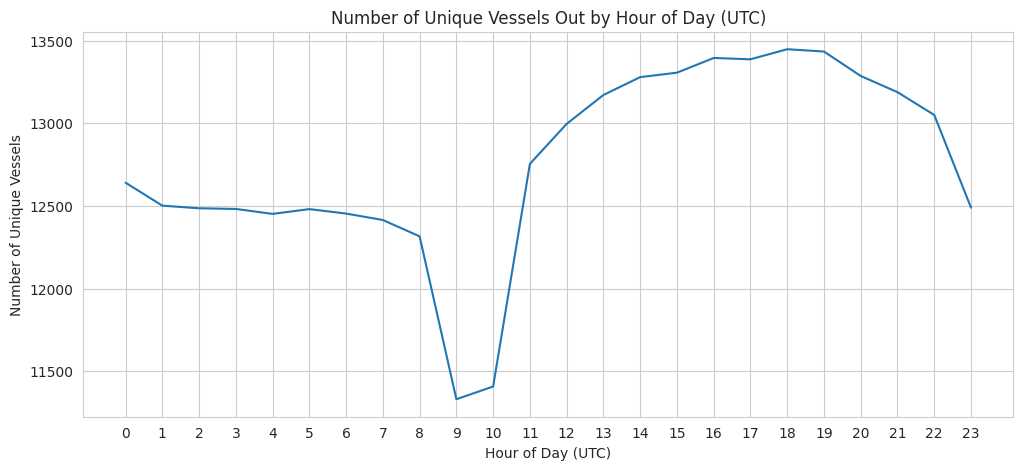

In [14]:
# Now let's make the line graph
import seaborn as sns
import matplotlib.pyplot as plt

# df_grouped_by_hour.plot(kind="line")

# Analyzing the data
# we can sort the grouped_by_hour df by the vessel count to quickly see the row with the highest and lowest vessel count
hour_with_most_boats = df_grouped_by_hour.sort_values(ascending=False).head(1)
hour_with_least_boats = df_grouped_by_hour.sort_values(ascending=True).head(1)
print()
print(f"The hour and count with the most boats out is: {hour_with_most_boats}")
print()
print(f"The hour and count with the least boats out is: {hour_with_least_boats}")
print()

# However, this would not show us if two or more different hours were "tied" on the maximum or minimum number of boats out. To more accurately do the analysis we can use min and max to get the count of vessels and then filter on the df to get show the hour(s) with those vessel counts

max_vessel_count = df_grouped_by_hour.max()
print(f"The maximum number of unique vessels out in any hour is: {max_vessel_count}.")
is_max_vessel_count = df_grouped_by_hour == max_vessel_count
print(f"The hour(s) which had the maximum vessel count are:")
print(df_grouped_by_hour[is_max_vessel_count])
hour_of_max = df_grouped_by_hour.idxmax() # the index is the hour
# idxmax() returns only the first occurrence if there are ties
print(f"One hour with the maximum (first occurrence) is: {hour_of_max}.")
print()

min_vessel_count = df_grouped_by_hour.min()
print(f"The minimum number of unique vessels out in any hour is: {min_vessel_count}.")
is_min_vessel_count = df_grouped_by_hour == min_vessel_count
print(f"The hour(s) which had the minimum vessel count are:")
print(df_grouped_by_hour[is_min_vessel_count])
hour_of_min = df_grouped_by_hour.idxmin() # the index is the hour
# idxmin() returns only the first occurrence if there are ties
print(f"One hour with the minimum (first occurrence) is: {hour_of_min}.")
print()

print("There is a sharp dip between hours 8 and 9, followed by a sharp increase between 10 and 11, with the peak at 18. ")
print("This may reflect changes in maritime activity throughout the day, such as vessels arriving at or departing from ports.")
# resetting the index so that I can reference the hour column when plotting with seaborn
print()
print(f"Before resetting, the index is: {df_grouped_by_hour.index}")
df_to_graph = df_grouped_by_hour.reset_index(level=0)
print(f"After resetting, the index is: {df_to_graph.index}")

# Let's rename the columns
print()
print(f"Before renaming, the columns are: {df_to_graph.columns}")
df_to_graph = df_to_graph.rename(columns={"base_date_time": "hour_of_day_UTC", "mmsi": "count_of_boats_out"})
print(f"After renaming, the columns are: {df_to_graph.columns}")
print()

x_axis = "hour_of_day_UTC"
y_axis = "count_of_boats_out"

# set the seaborn style and figure size
sns.set_style("whitegrid")
plt.figure(figsize=(12, 5)) # rectangle instead of square

sns.lineplot(data=df_to_graph, x=x_axis, y=y_axis)

plt.title("Number of Unique Vessels Out by Hour of Day (UTC)")
plt.xlabel("Hour of Day (UTC)")
plt.ylabel("Number of Unique Vessels")

plt.xticks(range(24))  # forces ticks at every hour 0–23
plt.show()

## Second Analysis: let's look at a specific boat, the Henry Hudson (MMSI: 366651000).

### The owner of the boat has asked us how long the boat engines were active for that day.

In [15]:
# filter rows of the entire valid df for only the Henry Hudson
is_henry_hudson = df_valid["mmsi"] == 366651000
df_hh = df_valid[is_henry_hudson]
print(df_hh.index)
print(f"Is the index unique? {df_hh.index.is_unique}")
print(f"There are {len(df_hh)} rows for the Henry Hudson")

DatetimeIndex(['2025-01-08 00:00:04+00:00', '2025-01-08 00:01:14+00:00',
               '2025-01-08 00:02:45+00:00', '2025-01-08 00:05:06+00:00',
               '2025-01-08 00:06:45+00:00', '2025-01-08 00:07:55+00:00',
               '2025-01-08 00:10:35+00:00', '2025-01-08 00:09:06+00:00',
               '2025-01-08 00:12:03+00:00', '2025-01-08 00:14:33+00:00',
               ...
               '2025-01-08 22:42:30+00:00', '2025-01-08 22:55:11+00:00',
               '2025-01-08 23:01:10+00:00', '2025-01-08 23:03:12+00:00',
               '2025-01-08 23:15:32+00:00', '2025-01-08 23:26:22+00:00',
               '2025-01-08 23:41:09+00:00', '2025-01-08 23:42:38+00:00',
               '2025-01-08 23:49:13+00:00', '2025-01-08 23:50:19+00:00'],
              dtype='datetime64[ns, UTC]', name='base_date_time', length=686, freq=None)
Is the index unique? True
There are 686 rows for the Henry Hudson


In [16]:
# a) Figure out when the Henry Hudson was "accelerating". Create a column called "acceleration", which is going to be the difference between each "sog". Hints: to achieve this, use the "diff()" function on your column. Be sure that your index is sorted, meaning the rows are sorted by time (.sort_index() is very helpful for this)
df_hh_sorted = df_hh.sort_index()
# checking the sort
# print(df_hh_sorted.head(3))
# print(df_hh_sorted.tail(3))

df_hh_sorted["acceleration"] = df_hh_sorted["sog"].diff() # add the column
print("Manually check the acceleration column")
print(df_hh_sorted[["sog","acceleration"]])

Manually check the acceleration column
                            sog  acceleration
base_date_time                               
2025-01-08 00:00:04+00:00   0.0           NaN
2025-01-08 00:01:14+00:00   5.5           5.5
2025-01-08 00:02:45+00:00  11.2           5.7
2025-01-08 00:03:55+00:00  11.6           0.4
2025-01-08 00:05:06+00:00  11.8           0.2
...                         ...           ...
2025-01-08 23:52:09+00:00  12.4          11.9
2025-01-08 23:53:38+00:00   4.3          -8.1
2025-01-08 23:55:19+00:00   0.0          -4.3
2025-01-08 23:57:09+00:00  10.7          10.7
2025-01-08 23:59:08+00:00  12.3           1.6

[686 rows x 2 columns]


In [17]:
# b) Create a duration column, which is the difference between each "base_date_time"
# Create a new dataframe with the duration column, which is the difference between each "base_date_time" which is the DatetimeIndex
df_hh_dur = df_hh_sorted.copy()
# Since base_date_time is not a column, we need to access the base_date_time index as a series to calculate the duration timedelta column using diff
df_hh_dur["duration"] = df_hh_dur.index.to_series().diff()
print("Manually checking the duration column:")
print()
print(df_hh_dur[["duration","acceleration","sog"]])
print(f"The index is still the same:\n{df_hh_dur.index}")
print(f"Manually check a specific interval (df_hh_sorted.index[5] - df_hh_sorted.index[4]): {df_hh_sorted.index[5] - df_hh_sorted.index[4]}")
print(f"Compare with df_hh_dur at iloc[5]: {df_hh_dur["duration"].iloc[5]}")

Manually checking the duration column:

                                 duration  acceleration   sog
base_date_time                                               
2025-01-08 00:00:04+00:00             NaT           NaN   0.0
2025-01-08 00:01:14+00:00 0 days 00:01:10           5.5   5.5
2025-01-08 00:02:45+00:00 0 days 00:01:31           5.7  11.2
2025-01-08 00:03:55+00:00 0 days 00:01:10           0.4  11.6
2025-01-08 00:05:06+00:00 0 days 00:01:11           0.2  11.8
...                                   ...           ...   ...
2025-01-08 23:52:09+00:00 0 days 00:01:50          11.9  12.4
2025-01-08 23:53:38+00:00 0 days 00:01:29          -8.1   4.3
2025-01-08 23:55:19+00:00 0 days 00:01:41          -4.3   0.0
2025-01-08 23:57:09+00:00 0 days 00:01:50          10.7  10.7
2025-01-08 23:59:08+00:00 0 days 00:01:59           1.6  12.3

[686 rows x 3 columns]
The index is still the same:
DatetimeIndex(['2025-01-08 00:00:04+00:00', '2025-01-08 00:01:14+00:00',
               '2025-01-08 0

In [18]:
# Once you have a column "acceleration" and "duration", we can assume that the boat engines were active if the "acceleration" is greater than 0. Filter your dataframe to only have rows where the acceleration is positive.
print("Before filtering:")
print(f"There are {len(df_hh_dur)} rows for the Henry Hudson.")
is_accelerating = df_hh_dur["acceleration"] > 0 # boolean filter
print(f"There are {len(df_hh_dur[is_accelerating])} rows when the boat is_accelerating")
print(f"There are {len(df_hh_dur[~is_accelerating])} rows when the boat is not accelerating that need to be filtered out.")
print()

df_hh_accelerating = df_hh_dur[is_accelerating]

print("After filtering:")
print(f"There are {len(df_hh_accelerating)} rows in the filtered dataframe.")
print(f"There are {len(df_hh_accelerating[df_hh_accelerating["acceleration"] <= 0])} rows where the boat is not accelerating (acceleration is less than or equal to zero).")
print(f"Check for nulls: {df_hh_accelerating.isnull().value_counts()}")


Before filtering:
There are 686 rows for the Henry Hudson.
There are 347 rows when the boat is_accelerating
There are 339 rows when the boat is not accelerating that need to be filtered out.

After filtering:
There are 347 rows in the filtered dataframe.
There are 0 rows where the boat is not accelerating (acceleration is less than or equal to zero).
Check for nulls: mmsi   longitude  latitude  sog    cog    heading  vessel_name  imo   call_sign  vessel_type  status  length  width  draft  cargo  transceiver  acceleration  duration
False  False      False     False  False  True     False        True  False      False        False   False   False  False  False  False        False         False       347
Name: count, dtype: int64


In [19]:
# Now we can answer the captain
# Sum up the "duration" column to see how long the engines were active for that day
active_engine_time = df_hh_accelerating["duration"].sum()

# Manually check the active engine time sum
total_time = df_hh_dur["duration"].sum()
print(f"The total time the boat was reporting that day (sum of all {len(df_hh_dur)} Henry Hudson rows): {total_time}")
print(f"The sum of only the accelerating duration column ({len(df_hh_accelerating)} rows) is: {active_engine_time}")
print("Manual check what % of the day the boat was accelerating")
print(f"Dividing active time by total time: {active_engine_time / total_time:.2f}")
timestamp_list = df_hh_accelerating.index.to_list()
date_to_analyze = timestamp_list[0].date()
print(f"To answer the captain, the boat engines were active for {active_engine_time} on {date_to_analyze}.")


The total time the boat was reporting that day (sum of all 686 Henry Hudson rows): 0 days 23:59:04
The sum of only the accelerating duration column (347 rows) is: 0 days 08:03:24
Manual check what % of the day the boat was accelerating
Dividing active time by total time: 0.34
To answer the captain, the boat engines were active for 0 days 08:03:24 on 2025-01-08.


# Bonus: create a function that takes the MMSI as a parameter, and return the active engine time for that day. Name this function calculate_total_active_engine_time.

In [22]:
def calculate_total_active_engine_time(df: pd.DataFrame, mmsi: int) -> pd.Timedelta:
  """
  This function takes the MMSI as a parameter and returns the active engine time
  for that day
  """
  # check to see if we have any data
  df_raw = df.copy()
  if len(df_raw) == 0:
    print("The dataframe has no rows")
    return -1

  # check to see if we have any data for this vessel (mmsi)
  is_mmsi = df_raw["mmsi"] == mmsi
  if len(df_raw[is_mmsi]) == 0:
    print("There are no rows for this vessel")
    return -1

  # create a dataframe with only the rows for this mmsi
  df_vessel = df_raw[is_mmsi]

  # clean the data
  # remove rows where sog is null
  is_valid_data = ~df_vessel["sog"].isnull()
  df_vessel = df_vessel[is_valid_data]
  if len(df_vessel) == 0:
    print("There are no valid rows for this vessel")
    return -1

  # convert the base_date_time to a timestamp
  df_vessel["base_date_time"] = pd.to_datetime(df_vessel["base_date_time"],utc=True)

  # set the index to the base_date_time (DateTimeIndex)
  df_vessel = df_vessel.set_index("base_date_time")

  # check that the index is unique
  if df_vessel.index.is_unique:
    pass
  else:
    print("The base_date_times reported for this vessel are not valid")
    return -1

  # sort the index
  df_vessel = df_vessel.sort_index()

  # figure out when this vessel was "accelerating"

  # create a column called "acceleration", which is going to be the difference between each "sog"
  df_vessel["acceleration"] = df_vessel["sog"].diff()

  # create a column called "duration", which is the difference between each "base_date_time" (the index)
  df_vessel["duration"] = df_vessel.index.to_series().diff()

  # assume that the boat engines were active if the "acceleration" is greater than 0. Filter the dataframe to only have rows where the acceleration is positive.
  is_accelerating = df_vessel["acceleration"] > 0 # boolean filter
  if len(df_vessel[is_accelerating]) == 0:
    print("This vessel was inactive the entire day")
    return 0

  # Sum up the "duration" column to see how long the engines were active for that day
  df_vessel_active = df_vessel[is_accelerating]
  total_active_engine_time = df_vessel_active.duration.sum()

  timestamp_list = df_vessel_active.index.to_list()
  date_to_analyze = timestamp_list[0].date()
  vessel_name = df_vessel.vessel_name.unique()
  print(f"The {vessel_name}'s engines were active for a total of {total_active_engine_time} on {date_to_analyze}.")
  return total_active_engine_time

In [23]:
# testing the function
mmsi = 366651000 # henry hudson
# mmsi = 367434220 # yogi berra
# mmsi = 368037610 # breezy point
# mmsi = 367719770 # thomas jefferson
# mmsi = 367313160 # san juan enterprise
total_time = calculate_total_active_engine_time(df, mmsi)
print(total_time)

The ['HENRY HUDSON']'s engines were active for a total of 0 days 08:03:24 on 2025-01-08.
0 days 08:03:24
